# Q-Learning Agent Training — Workflow Simulator

This notebook trains one **`QLearningAgent`** per microservice to jointly
control **CPU/replica allocation** and **node placement** for all services in a
simulated microservice application.

Training is episode-based: each episode is one full simulator run.  At every
evaluation event (fired every `EVAL_INTERVAL` seconds of simulated time) the
agent for each service observes service-level metrics, selects an action
(a `(node, cpu)` pair), and the simulator applies the action immediately.

After training the Q-tables and a metadata file describing the agent
configuration and its exact responsibilities are saved to a timestamped
sub-directory of `models/`.

## Step 1 — Imports

We import the project modules, standard library modules used for serialisation,
and matplotlib for plotting training curves.

`from simulator.simulation import Simulation` also **applies the module-level
monkey-patches** that give `QLearningAgent` concrete `get_state()` and
`reward()` implementations without modifying `agents.py`.

In [1]:
import sys
import os
import json
import pickle
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Ensure the project root is on the path when running from any working directory
sys.path.insert(0, str(Path.cwd()))

from simulator.application import Application
from simulator.infrastructure import Node
# Importing Simulation also applies QLearningAgent.get_state / .reward patches
from simulator.simulation import Simulation
from agents.agents import QLearningAgent

print("Imports OK")

Imports OK


## Step 2 — Configuration

All hyperparameters and topology constants are defined here so they can be
changed in a single place.

| Group | Parameter | Meaning |
|---|---|---|
| Topology | `APP_TOPOLOGY` | Explicit service/workflow call-graph definition |
| Topology | `N_SERVICES` | Number of microservices (derived from `APP_TOPOLOGY`) |
| Topology | `N_WORKFLOWS` | Number of workflow types (derived from `APP_TOPOLOGY`) |
| Topology | `N_NODES` | Number of infrastructure nodes |
| Topology | `CPU_MAX` | Max CPU threads available per node |
| Simulation | `ITERATIONS` | Simulation events processed per episode |
| Simulation | `EVAL_INTERVAL` | Simulated seconds between agent evaluations |
| RL | `EPSILON` | ε-greedy exploration rate |
| RL | `ALPHA` | Q-learning step size |
| RL | `GAMMA` | Discount factor |
| Training | `N_EPISODES` | Number of training episodes |
| Responsibilities | `AGENT_CONTROLS_REPLICAS` | Agent may change service CPU/threads |
| Responsibilities | `AGENT_CONTROLS_PLACEMENT` | Agent may migrate service to a different node |

**Agent assignment strategies** — three ready-to-use options are provided in
the config cell (only one should be active at a time):

| Strategy | Description |
|---|---|
| **A — by workflow** | One agent per workflow; works cleanly when service sets are disjoint |
| **B — by node** | One agent per hosting node; groups co-located services together |
| **C — single agent** | One agent controls all services |


In [2]:

from pathlib import Path
import random
import numpy as np

# -- Application topology -----------------------------------------------------
# Define services and workflow call graphs explicitly -- no randomness.
#
# "edges": [(caller_service_id, callee_service_id), ...]  describes the
#   downstream call chain for that workflow.  Must form a DAG.
# "root_service": entry-point service for the workflow.
# "lam": Poisson arrival rate (optional; random if omitted).
#
# The example below gives two fully disjoint workflows so each can be owned
# by a separate agent with no shared-service ambiguity:
#
#   wf0:  s0 --> s1          (e.g. frontend -> backend)
#   wf1:  s2 --> s3          (e.g. analytics -> store)
#
APP_TOPOLOGY = {
    "n_services": 4,
    "workflows": [
        {"id": 0, "lam": 0.50, "root_service": 0, "edges": [(0, 1)]},
        {"id": 1, "lam": 0.40, "root_service": 2, "edges": [(2, 3)]},
    ],
}

# Derived constants (kept for downstream cells that reference them)
N_SERVICES  = APP_TOPOLOGY["n_services"]
N_WORKFLOWS = len(APP_TOPOLOGY["workflows"])

# -- Infrastructure ------------------------------------------------------------
N_NODES = 3        # infrastructure nodes
CPU_MAX = 4        # max CPU threads per node
RAM     = 8        # RAM per node (arbitrary units)
FREQ    = 1000     # processing frequency per node (Hz)

# -- Simulation run ------------------------------------------------------------
ITERATIONS    = 600
TIMEOUT       = 600_000
EVAL_INTERVAL = 10.0
SEED          = 42

# -- RL hyperparameters --------------------------------------------------------
EPSILON       = 0.30
EPSILON_MIN   = 0.05
EPSILON_DECAY = 0.992
ALPHA         = 0.10
GAMMA         = 0.9

# -- Training ------------------------------------------------------------------
N_EPISODES        = 1000
EVAL_GREEDY_EVERY = 10

# -- Control flags -------------------------------------------------------------
AGENT_CONTROLS_REPLICAS  = True
AGENT_CONTROLS_PLACEMENT = False

# -- Agent responsibility assignment ------------------------------------------
# Choose ONE strategy by uncommenting the desired block.
# Each key is "s<service_id+1>.<control>" -- 1-based service notation.
#
# -- Strategy A: one agent per workflow (works cleanly with disjoint services) -
AGENT_CONTROL_ASSIGNMENTS = {
    "s1.scaling": "agent1",   # service 0  -| wf0: s0 -> s1
    "s2.scaling": "agent1",   # service 1  -|
    "s3.scaling": "agent2",   # service 2  -| wf1: s2 -> s3
    "s4.scaling": "agent2",   # service 3  -|
}

# -- Strategy B: one agent per initial node (round-robin placement) -----------
# Initial placement with N_NODES=3: s0->node0, s1->node1, s2->node2, s3->node0
# AGENT_CONTROL_ASSIGNMENTS = {
#     "s1.scaling": "agent_node0",   # service 0 on node 0
#     "s2.scaling": "agent_node1",   # service 1 on node 1
#     "s3.scaling": "agent_node2",   # service 2 on node 2
#     "s4.scaling": "agent_node0",   # service 3 on node 0 (co-located with s0)
# }

# -- Strategy C: single agent controls everything ------------------------------
# AGENT_CONTROL_ASSIGNMENTS = {
#     "s1.scaling": "agent",
#     "s2.scaling": "agent",
#     "s3.scaling": "agent",
#     "s4.scaling": "agent",
# }

# -- Reward normalisation and weighting ----------------------------------------
E2E_LAT_TARGET = 4.0
REWARD_CPU_WEIGHT = 0.50
REWARD_LAT_VIOL_WEIGHT = 0.50

MODELS_DIR = Path("models")

np.random.seed(SEED)
random.seed(SEED)
print("Configuration OK")
print(f"  n_services={N_SERVICES}  n_workflows={N_WORKFLOWS}  n_nodes={N_NODES}  cpu_max={CPU_MAX}")
print(f"  active strategy: {sorted(set(AGENT_CONTROL_ASSIGNMENTS.values()))}")
print(f"  reward weights: cpu={REWARD_CPU_WEIGHT} latency_violation={REWARD_LAT_VIOL_WEIGHT}")


Configuration OK
  n_services=4  n_workflows=2  n_nodes=3  cpu_max=4
  active strategy: ['agent1', 'agent2']
  reward weights: cpu=0.5 latency_violation=0.5


## Step 3 — Build the Environment

`Application(topology=APP_TOPOLOGY)` constructs a **fully deterministic**
application from the topology dict defined in Step 2.  The dict specifies:

- how many services exist (`n_services`)
- for each workflow: the entry-point service, the downstream call edges, and
  the Poisson arrival rate (`lam`)

Using an explicit topology means the `service → workflows` mapping is known
before training, so `AGENT_CONTROL_ASSIGNMENTS` can be written precisely
(e.g. by workflow, by hosting node, or any other grouping).

`Node` objects represent the physical/virtual machines.  Services are placed
round-robin across nodes and start with the maximum thread count.


In [3]:
app = Application(topology=APP_TOPOLOGY)
print(f"Services : {len(app.services)}")
print(f"Workflows: {len(app.workflows)}")

# Infrastructure nodes
nodes = [Node(i, CPU_MAX, RAM, FREQ) for i in range(N_NODES)]

# Initial service → node mapping (round-robin)
initial_service_map = {s.id: nodes[s.id % N_NODES] for s in app.services}
app.deploy_services(initial_service_map)

# Give each service the full thread budget at the start
for s in app.services:
    s.threads = CPU_MAX

app.reset()

print()
print("Initial placement:")
for s in app.services:
    print(f"  service {s.id} → node {s.node.id}  threads={s.threads}")


Services: 4
Tasktrees: 2
[0, 1]
[2, 3]
Labels: {0: 0, 1: 1, 2: 2, 3: 3}
Services : 4
Workflows: 2

Initial placement:
  service 0 → node 0  threads=4
  service 1 → node 1  threads=4
  service 2 → node 2  threads=4
  service 3 → node 0  threads=4


## Step 4 — Per-Service Action Spaces

Each agent selects an **integer index** into a fixed list of `(node_id, cpu)`
pairs — its *action space*.  The simulator's `_apply_agent_action()` then
decodes that pair and migrates / re-allocates the service accordingly.

The action space is the Cartesian product of the available **node pool** and
the allowed **CPU counts**, filtered by the responsibility flags:

- If `AGENT_CONTROLS_PLACEMENT=False`, every action keeps the service on its
  current node (only CPU changes).
- If `AGENT_CONTROLS_REPLICAS=False`, every action keeps CPU at `CPU_MAX`
  (only placement changes).

> **Example** — 3 nodes, CPU ∈ {1,2,3,4}, both controls enabled →
> 3 × 4 = **12 actions** per service.

In [4]:

from itertools import product


def normalize_control_name(name):
    n = str(name).strip().lower()
    if n in ("scaling", "replicas", "cpu"):
        return "cpu"
    if n in ("migration", "placement", "node"):
        return "node"
    raise ValueError(f"Unsupported control name: {name}")


def parse_service_token(token, service_ids):
    t = str(token).strip().lower()
    if not t.startswith("s") or len(t) < 2:
        raise ValueError(f"Invalid service token: {token}")

    raw_num = int(t[1:])

    # If service id 0 exists, default to 1-based notation (s1 -> 0).
    if 0 in service_ids and (raw_num - 1) in service_ids:
        return raw_num - 1

    if raw_num in service_ids:
        return raw_num
    if (raw_num - 1) in service_ids:
        return raw_num - 1

    raise ValueError(
        f"Service token '{token}' does not match service ids {service_ids}. "
        f"Accepted forms are s<id> or 1-based s<id+1>."
    )


def normalize_assignments(raw_assignments, service_ids):
    by_agent = {}

    for key, agent_name in raw_assignments.items():
        parts = str(key).split(".", 1)
        if len(parts) != 2:
            raise ValueError(f"Invalid assignment key '{key}'. Expected format 'sX.control'.")

        service_token, control_token = parts
        sid = parse_service_token(service_token, service_ids)
        control = normalize_control_name(control_token)

        agent_key = str(agent_name).strip()
        if not agent_key:
            raise ValueError(f"Invalid empty agent name for key '{key}'.")

        by_agent.setdefault(agent_key, set()).add((sid, control))

    return by_agent


def validate_assignments(by_agent, service_ids, active_service_ids):
    enabled_controls = set()
    if AGENT_CONTROLS_REPLICAS:
        enabled_controls.add("cpu")
    if AGENT_CONTROLS_PLACEMENT:
        enabled_controls.add("node")

    required_pairs = {(sid, ctrl) for sid in active_service_ids for ctrl in enabled_controls}

    assigned_pairs = set()
    duplicates = set()
    invalid_controls = set()
    inactive_assignments = set()

    for pairs in by_agent.values():
        for sid, ctrl in pairs:
            if ctrl not in enabled_controls:
                invalid_controls.add((sid, ctrl))
            if sid not in active_service_ids:
                inactive_assignments.add((sid, ctrl))
            if (sid, ctrl) in assigned_pairs:
                duplicates.add((sid, ctrl))
            assigned_pairs.add((sid, ctrl))

    if invalid_controls:
        raise ValueError(
            "Assignments include disabled controls: "
            + ", ".join(f"s{sid}.{ctrl}" for sid, ctrl in sorted(invalid_controls))
        )

    if inactive_assignments:
        raise ValueError(
            "Assignments include inactive services (no workflow traffic): "
            + ", ".join(f"s{sid}.{ctrl}" for sid, ctrl in sorted(inactive_assignments))
        )

    missing = sorted(required_pairs - assigned_pairs)
    if missing:
        raise ValueError(
            "Missing active service/control assignments: "
            + ", ".join(f"s{sid}.{ctrl}" for sid, ctrl in missing)
        )

    if duplicates:
        raise ValueError(
            "Duplicate service/control assignments detected: "
            + ", ".join(f"s{sid}.{ctrl}" for sid, ctrl in sorted(duplicates))
        )


def build_agent_action_space(responsibilities, node_pool, cpu_actions):
    # responsibilities: [(service_id, 'cpu'|'node'), ...]
    dimensions = []
    for sid, control in responsibilities:
        options = list(cpu_actions) if control == "cpu" else list(node_pool)
        dimensions.append((sid, control, options))

    if not dimensions:
        return [{}]

    option_lists = [opts for _, _, opts in dimensions]
    action_space = []

    for combo in product(*option_lists):
        action = {}
        for (sid, control, _), value in zip(dimensions, combo):
            action.setdefault(sid, {})[control] = value
        action_space.append(action)

    return action_space


service_ids = [s.id for s in app.services]
active_service_ids = sorted({int(app.task_graph.nodes[n]["subset"]) for n in app.task_graph.nodes})

cpu_action_set = list(range(1, CPU_MAX + 1))
node_pool_all = [node.id for node in nodes]

# Build service → workflows mapping: which workflow IDs involve each service.
service_to_workflows = {}
for wf in app.workflows:
    for task_node in wf.nodes:
        sid = int(app.task_graph.nodes[task_node]["subset"])
        service_to_workflows.setdefault(sid, set()).add(wf.id)
service_to_workflows = {k: sorted(v) for k, v in service_to_workflows.items()}

assignments_by_agent = normalize_assignments(AGENT_CONTROL_ASSIGNMENTS, service_ids)
validate_assignments(assignments_by_agent, service_ids, active_service_ids)

agent_specs = []
for agent_name in sorted(assignments_by_agent.keys()):
    responsibilities = sorted(assignments_by_agent[agent_name], key=lambda x: (x[0], x[1]))
    action_space = build_agent_action_space(responsibilities, node_pool_all, cpu_action_set)

    # Collect the workflow IDs that pass through any of this agent's services.
    s_scope = {sid for sid, _ in responsibilities}
    workflow_scope = sorted({wid for sid in s_scope for wid in service_to_workflows.get(sid, [])})

    agent_specs.append({
        "name": agent_name,
        "responsibilities": responsibilities,
        "action_space": action_space,
        "workflow_scope": workflow_scope,
    })

print("Active services in workflows:", active_service_ids)
print("Service → workflows map:", service_to_workflows)
print("Global agent/action setup:")
for i, spec in enumerate(agent_specs):
    readable_resp = [f"s{sid}.{ctrl}" for sid, ctrl in spec["responsibilities"]]
    print(
        f"  global_agent[{i}] name={spec['name']} "
        f"responsibilities={readable_resp} n_actions={len(spec['action_space'])} "
        f"workflow_scope={spec['workflow_scope']}"
    )
    print(f"    sample action: {spec['action_space'][0]}")


Active services in workflows: [0, 1, 2, 3]
Service → workflows map: {0: [0], 1: [0], 2: [1], 3: [1]}
Global agent/action setup:
  global_agent[0] name=agent1 responsibilities=['s0.cpu', 's1.cpu'] n_actions=16 workflow_scope=[0]
    sample action: {0: {'cpu': 1}, 1: {'cpu': 1}}
  global_agent[1] name=agent2 responsibilities=['s2.cpu', 's3.cpu'] n_actions=16 workflow_scope=[1]
    sample action: {2: {'cpu': 1}, 3: {'cpu': 1}}


## Step 5 — Agent Initialisation

One `QLearningAgent` is created per service.  Its `actions` list is the set of
valid **integer indices** into that service's action-space list — not the raw
`(node, cpu)` tuples.  The decoding from index to `(node, cpu)` happens in the
dispatcher (Step 6).

The Q-table starts empty: all `Q(s, a) = 0`.  The monkey-patched `get_state`
encodes state as `(min(queue_size, cap), min(cpu, cap))`, giving a small,
bounded discrete state space that converges quickly.

In [5]:

def make_agent_get_state(responsibilities, q_cap=20, cpu_cap=20):
    service_scope = sorted({sid for sid, _ in responsibilities})

    def _get_state(self, observations):
        queues = observations.get("service_queues", [])
        cpus = observations.get("service_cpus", [])

        state = []
        for sid in service_scope:
            state.append(min(int(queues[sid]), q_cap))
        for sid in service_scope:
            state.append(min(int(cpus[sid]), cpu_cap))
        return tuple(state)

    return _get_state


def make_agent_reward(responsibilities, workflow_scope):
    """
    Reward = negative weighted sum of normalized penalties:
      - normalized CPU usage percentage (actual_average_cpu / CPU_MAX) on hosting nodes
      - normalized per-request latency violation rate on scoped workflows

    Both terms are in [0, 1] and combined with configured weights.
    """
    service_scope = sorted({sid for sid, _ in responsibilities})

    total_w = float(REWARD_CPU_WEIGHT) + float(REWARD_LAT_VIOL_WEIGHT)
    if total_w <= 0:
        cpu_w = 0.5
        lat_w = 0.5
    else:
        cpu_w = float(REWARD_CPU_WEIGHT) / total_w
        lat_w = float(REWARD_LAT_VIOL_WEIGHT) / total_w

    lat_target = max(float(E2E_LAT_TARGET), 1e-12)

    def _reward(self, observations):
        workflow_violation_rates = observations.get("workflow_violation_rates", [])
        workflow_e2e_means = observations.get("workflow_e2e_means", [])
        service_node_ids = observations.get("service_node_ids", [])
        node_cpu_usage_pct = observations.get("node_cpu_usage_pct", {})

        # -- Workflow violation rate from individual requests ---------------------
        lat_violations = []
        for wid in workflow_scope:
            if wid < len(workflow_violation_rates):
                viol_rate = float(workflow_violation_rates[wid])
            else:
                # Fallback if simulator metrics are unavailable.
                e2e = float(workflow_e2e_means[wid]) if wid < len(workflow_e2e_means) else 0.0
                viol_rate = max(0.0, (e2e - lat_target) / lat_target)
            lat_violations.append(min(1.0, max(0.0, viol_rate)))
        mean_lat_violation = float(np.mean(lat_violations)) if lat_violations else 0.0

        # -- Node CPU usage percentage (actual_average_cpu / CPU_MAX) ------------
        node_scope = sorted({service_node_ids[sid] for sid in service_scope}) if service_scope else []
        cpu_usages = []
        for nid in node_scope:
            usage = float(node_cpu_usage_pct.get(nid, 0.0))
            cpu_usages.append(min(1.0, max(0.0, usage)))
        mean_cpu_usage = float(np.mean(cpu_usages)) if cpu_usages else 0.0

        penalty = cpu_w * mean_cpu_usage + lat_w * mean_lat_violation
        return 1.0 - float(penalty)

    return _reward


global_agents = []
for spec in agent_specs:
    n_actions = len(spec["action_space"])
    agent = QLearningAgent(
        epsilon=EPSILON,
        alpha=ALPHA,
        gamma=GAMMA,
        actions=list(range(n_actions)),
    )

    agent.get_state = make_agent_get_state(spec["responsibilities"]).__get__(agent, QLearningAgent)
    agent.reward = make_agent_reward(
        spec["responsibilities"], spec["workflow_scope"]
    ).__get__(agent, QLearningAgent)

    global_agents.append({
        "name": spec["name"],
        "responsibilities": spec["responsibilities"],
        "workflow_scope": spec["workflow_scope"],
        "action_space": spec["action_space"],
        "agent": agent,
    })

for i, item in enumerate(global_agents):
    readable_resp = [f"s{sid}.{ctrl}" for sid, ctrl in item["responsibilities"]]
    print(
        f"global_agent[{i}] name={item['name']} responsibilities={readable_resp} "
        f"workflow_scope={item['workflow_scope']} "
        f"n_actions={len(item['action_space'])} epsilon={EPSILON} alpha={ALPHA} gamma={GAMMA}"
    )


global_agent[0] name=agent1 responsibilities=['s0.cpu', 's1.cpu'] workflow_scope=[0] n_actions=16 epsilon=0.3 alpha=0.1 gamma=0.9
global_agent[1] name=agent2 responsibilities=['s2.cpu', 's3.cpu'] workflow_scope=[1] n_actions=16 epsilon=0.3 alpha=0.1 gamma=0.9


## Step 6 — Observation Builder & Agent Dispatcher

`AgentDispatcher` is a thin adapter that:

1. Receives the simulation's `on_eval(service_idx, service, accumulated_metrics,
   instant_metrics)` callback.
2. Flattens the nested metrics dicts into a single `observations` dict that
   `QLearningAgent.step()` expects.
3. Decodes the integer action index returned by `step()` back to a
   `{"node": node_id, "cpu": cpu}` dict that `_apply_agent_action()` consumes.

| Observation key | Source |
|---|---|
| `queue_size` | instant: tasks in queue + running |
| `cpu` | instant: current thread count |
| `avg_latency` | accumulated: mean task latency this interval |
| `avg_throughput` | accumulated: arrivals / departures ratio |
| `avg_success_rate` | accumulated: % of workflows completed successfully |

In [6]:

class GlobalAgentDispatcher:
    """
    Single dispatcher shared by all services.
    The simulator still calls on_eval(service_idx, ...), but this dispatcher
    computes a global action plan once per eval cycle and returns the part for
    each requested service.
    """

    def __init__(self, service_ids, global_agents):
        self.service_ids = list(service_ids)
        self.global_agents = global_agents
        self._eval_counter = 0
        self._planned_actions = {}
        self._last_node_metric_idx = {node.id: 0 for node in nodes}

    def _build_observations(self, accumulated_metrics, instant_metrics):
        services_now = instant_metrics["services"]
        services_acc = accumulated_metrics["services"]

        queues = [s["queue_size"] for s in services_now]
        cpus = [s["cpu"] for s in services_now]
        node_ids = [s["node_id"] for s in services_now]

        service_latency_means = [float(s["avg_latency"]) for s in services_acc]
        service_throughput_means = [float(s["avg_throughput"]) for s in services_acc]

        avg_latency_mean = sum(service_latency_means) / len(service_latency_means)
        avg_throughput_mean = sum(service_throughput_means) / len(service_throughput_means)

        node_queue_totals = {}
        for sid, nid in enumerate(node_ids):
            node_queue_totals[nid] = node_queue_totals.get(nid, 0.0) + float(queues[sid])

        # Use actual node CPU usage over the latest eval window.
        node_cpu_usage_pct = {}
        node_avg_threads = {}
        for node in nodes:
            arr = np.array(node.cpu_metric, dtype=float)
            start = int(self._last_node_metric_idx.get(node.id, 0))
            seg = arr[start:] if start < arr.size else np.array([], dtype=float)
            avg_cpu = float(np.mean(seg)) if seg.size > 0 else 0.0
            node_avg_threads[node.id] = avg_cpu
            node_cpu_usage_pct[node.id] = min(1.0, max(0.0, avg_cpu / max(float(CPU_MAX), 1e-12)))
            self._last_node_metric_idx[node.id] = arr.size

        workflow_e2e_means = accumulated_metrics["workflows"].get("e2e_latencies", [])
        workflow_violation_rates = accumulated_metrics["workflows"].get("violation_rates", [])

        return {
            "service_queues": queues,
            "service_cpus": cpus,
            "service_node_ids": node_ids,
            "service_latency_means": service_latency_means,
            "service_throughput_means": service_throughput_means,
            "node_queue_totals": node_queue_totals,
            "node_cpu_usage_pct": node_cpu_usage_pct,
            "node_avg_threads": node_avg_threads,
            "workflow_e2e_means": workflow_e2e_means,
            "workflow_violation_rates": workflow_violation_rates,
            "avg_queue": sum(queues) / len(queues),
            "avg_latency_mean": avg_latency_mean,
            "avg_throughput_mean": avg_throughput_mean,
            "avg_success_rate": accumulated_metrics["workflows"]["avg_success_rate"],
        }

    def _compute_plan(self, accumulated_metrics, instant_metrics):
        observations = self._build_observations(accumulated_metrics, instant_metrics)
        combined = {sid: {} for sid in self.service_ids}

        for item in self.global_agents:
            agent = item["agent"]
            action_space = item["action_space"]

            action_idx = int(agent.step(observations))
            action_idx = max(0, min(action_idx, len(action_space) - 1))
            partial_plan = action_space[action_idx]

            for sid, partial_action in partial_plan.items():
                combined[sid].update(partial_action)

        self._planned_actions = combined

    def on_eval(self, service_idx, service, accumulated_metrics, instant_metrics):
        if self._eval_counter % len(self.service_ids) == 0:
            self._compute_plan(accumulated_metrics, instant_metrics)
        self._eval_counter += 1

        action = self._planned_actions.get(service.id, {})
        return action if action else None

    def reset_environment(self):
        for item in self.global_agents:
            item["agent"].reset_environment()
        self._last_node_metric_idx = {node.id: 0 for node in nodes}
        self._eval_counter = 0

    def get_epsilons(self):
        return [item["agent"].epsilon for item in self.global_agents]

    def set_epsilons(self, epsilons, reset=False):
        for item, eps in zip(self.global_agents, epsilons):
            item["agent"].epsilon = eps
            if reset:
                item["agent"].reset_environment()

    def total_reward(self):
        return sum(sum(item["agent"].rewards) for item in self.global_agents)

    def qtables(self):
        return {item["name"]: item["agent"].q_table for item in self.global_agents}


# One global dispatcher instance, wired into simulator's existing interface.
global_dispatcher = GlobalAgentDispatcher(service_ids, global_agents)
dispatchers = {sid: global_dispatcher for sid in service_ids}

print("Global dispatcher registered for services:", list(dispatchers.keys()))
print("Internal global agents:", len(global_dispatcher.global_agents))


Global dispatcher registered for services: [0, 1, 2, 3]
Internal global agents: 2


## Step 7 — Training Loop

Each episode:
1. **Reset** the application and nodes to the initial state (original placement,
   full thread count, empty queues).
2. **Reset agent episode state** (`state`, `action`, `rewards`) while keeping
   the Q-table intact — learning persists across episodes.
3. **Run** one full simulation episode with the dispatchers hooked up.
4. **Collect** the cumulative reward from each agent.

Every `EVAL_GREEDY_EVERY` episodes an additional **greedy evaluation** episode
(ε = 0) is run to measure the current policy's workflow success rate without
exploration noise.

In [7]:
episode_total_rewards      = []
episode_per_agent_rewards  = {item["name"]: [] for item in global_agents}
greedy_success_rates       = []
greedy_episodes            = []

# Additional episode-level metrics for plotting
episode_workflow_violation_pct = {wf.id: [] for wf in app.workflows}
episode_workflow_avg_latency = {wf.id: [] for wf in app.workflows}
episode_avg_violation_pct = []
episode_node_cpu_usage_pct = {node.id: [] for node in nodes}
episode_node_avg_threads = {node.id: [] for node in nodes}

# Build a task_id -> workflow_id lookup once (task ids are unique across workflows).
task_to_workflow = {}
for wf in app.workflows:
    for task_id in wf.nodes:
        task_to_workflow[int(task_id)] = int(wf.id)

# Root task per workflow for e2e latency extraction from sim.history.
workflow_root_task = {int(wf.id): int(wf.initial_task.id) for wf in app.workflows}

for ep in range(N_EPISODES):

    # -- 1. Reset environment to its initial state -----------------------------
    for s in app.services:
        s.node = initial_service_map[s.id]
        s.threads = CPU_MAX
    app.reset()

    # -- 2. Reset agent episode state (Q-table is preserved) -------------------
    global_dispatcher.reset_environment()

    # -- 3. Run one training episode -------------------------------------------
    sim = Simulation(
        [app], [],
        ITERATIONS,
        step_size=ITERATIONS,
        alloc_step_size=1,
        timeout=TIMEOUT,
        eval_interval=EVAL_INTERVAL,
        latency_target=E2E_LAT_TARGET,
    )
    sim.run(agents=dispatchers)

    # -- 4. Collect per-agent and total rewards --------------------------------
    ep_total = global_dispatcher.total_reward()
    episode_total_rewards.append(ep_total)

    for item in global_agents:
        episode_per_agent_rewards[item["name"]].append(sum(item["agent"].rewards))

    # -- 4b. Collect per-workflow latency and violations from individual requests
    per_wf_lat_samples = {wf.id: [] for wf in app.workflows}
    per_wf_viol_samples = {wf.id: [] for wf in app.workflows}
    total_req = 0
    total_viol = 0

    for trace_data in sim.history.values():
        if int(trace_data.get("status", -1)) != 1:
            continue

        # Find the workflow this trace belongs to from any task id key.
        task_keys = [k for k in trace_data.keys() if k != "status"]
        if not task_keys:
            continue
        wf_id = None
        for tkey in task_keys:
            wf_id = task_to_workflow.get(int(tkey))
            if wf_id is not None:
                break
        if wf_id is None:
            continue

        root_task_id = workflow_root_task.get(wf_id)
        root_times = trace_data.get(root_task_id)
        if root_times is None or len(root_times) < 2:
            continue

        e2e_latency = float(root_times[-1] - root_times[0])
        violated = 1.0 if e2e_latency > E2E_LAT_TARGET else 0.0

        per_wf_lat_samples[wf_id].append(e2e_latency)
        per_wf_viol_samples[wf_id].append(violated)
        total_req += 1
        total_viol += int(violated)

    for wf in app.workflows:
        lat_samples = per_wf_lat_samples[wf.id]
        viol_samples = per_wf_viol_samples[wf.id]
        episode_workflow_avg_latency[wf.id].append(float(np.mean(lat_samples)) if lat_samples else 0.0)
        episode_workflow_violation_pct[wf.id].append(100.0 * float(np.mean(viol_samples)) if viol_samples else 0.0)

    avg_viol_pct = (100.0 * total_viol / total_req) if total_req > 0 else 0.0
    episode_avg_violation_pct.append(avg_viol_pct)

    # -- 4c. Collect per-node CPU usage and avg threads -------------------------
    for node in nodes:
        cpu_arr = np.array(node.cpu_metric, dtype=float)
        avg_threads = float(np.mean(cpu_arr)) if cpu_arr.size > 0 else 0.0
        usage_pct = 100.0 * avg_threads / max(float(CPU_MAX), 1e-12)
        episode_node_avg_threads[node.id].append(avg_threads)
        episode_node_cpu_usage_pct[node.id].append(min(100.0, max(0.0, usage_pct)))

    # -- 5. Epsilon decay for continued exploration -> exploitation ------------
    decayed_eps = [max(EPSILON_MIN, eps * EPSILON_DECAY) for eps in global_dispatcher.get_epsilons()]
    global_dispatcher.set_epsilons(decayed_eps, reset=False)

    # -- 6. Periodic greedy evaluation (no exploration) ------------------------
    if (ep + 1) % EVAL_GREEDY_EVERY == 0:
        saved_eps = global_dispatcher.get_epsilons()
        global_dispatcher.set_epsilons([0.0] * len(saved_eps), reset=True)

        for s in app.services:
            s.node = initial_service_map[s.id]
            s.threads = CPU_MAX
        app.reset()

        eval_sim = Simulation(
            [app], [],
            ITERATIONS,
            step_size=ITERATIONS,
            alloc_step_size=1,
            timeout=TIMEOUT,
            eval_interval=EVAL_INTERVAL,
            latency_target=E2E_LAT_TARGET,
        )
        eval_sim.run(agents=dispatchers)

        completed = sum(1 for v in eval_sim.history.values() if v.get("status") == 1)
        total_tr = len(eval_sim.history)
        success = 100.0 * completed / total_tr if total_tr > 0 else 0.0
        greedy_success_rates.append(success)
        greedy_episodes.append(ep + 1)

        global_dispatcher.set_epsilons(saved_eps, reset=False)

        print(
            f"Episode {ep+1:4d}/{N_EPISODES}  "
            f"train_reward={ep_total:8.3f}  "
            f"avg_viol={avg_viol_pct:6.2f}%  "
            f"greedy_success={success:.1f}%  "
            f"eps={saved_eps[0]:.3f}"
        )

print("\nTraining complete.")












Episode   10/1000  train_reward=  26.723  avg_viol= 26.21%  greedy_success=100.0%  eps=0.277











Episode   20/1000  train_reward=  19.103  avg_viol= 31.94%  greedy_success=98.0%  eps=0.255











Episode   30/1000  train_reward=  21.989  avg_viol= 32.64%  greedy_success=98.0%  eps=0.236











Episode   40/1000  train_reward=  21.300  avg_viol= 23.61%  greedy_success=98.0%  eps=0.218











Episode   50/1000  train_reward=  18.188  avg_viol= 29.66%  greedy_success=98.6%  eps=0.201











Episode   60/1000  train_reward=  20.416  avg_viol= 36.11%  greedy_success=98.6%  eps=0.185











Episode   70/1000  train_reward=  24.718  avg_viol= 29.37%  greedy_success=97.3%  eps=0.171











Episode   80/1000  train_reward=  24.845  avg_viol= 24.83%  greedy_success=96.6%  eps=0.158











Episode   90/1000  train_reward=  22.636  avg_viol= 26.90%  greedy_success=98.6%  eps=0.146











Episode  100/1000  train_reward=  24.676  avg_viol= 11.81%  g

## Step 8 -- Plot Training Curves

This section produces three outputs:

1. `training_curves.png` with overall training diagnostics.
2. `training_curves_per_agent_raw.png` with raw per-agent rewards.
3. `training_metrics_requested.png` with the requested operational metrics:

- CPU usage percentage per node (`actual_average_cpu / CPU_MAX`)
- average thread number per node
- average violations percentage in each episode
- average latency per workflow in each episode
- reward per agent


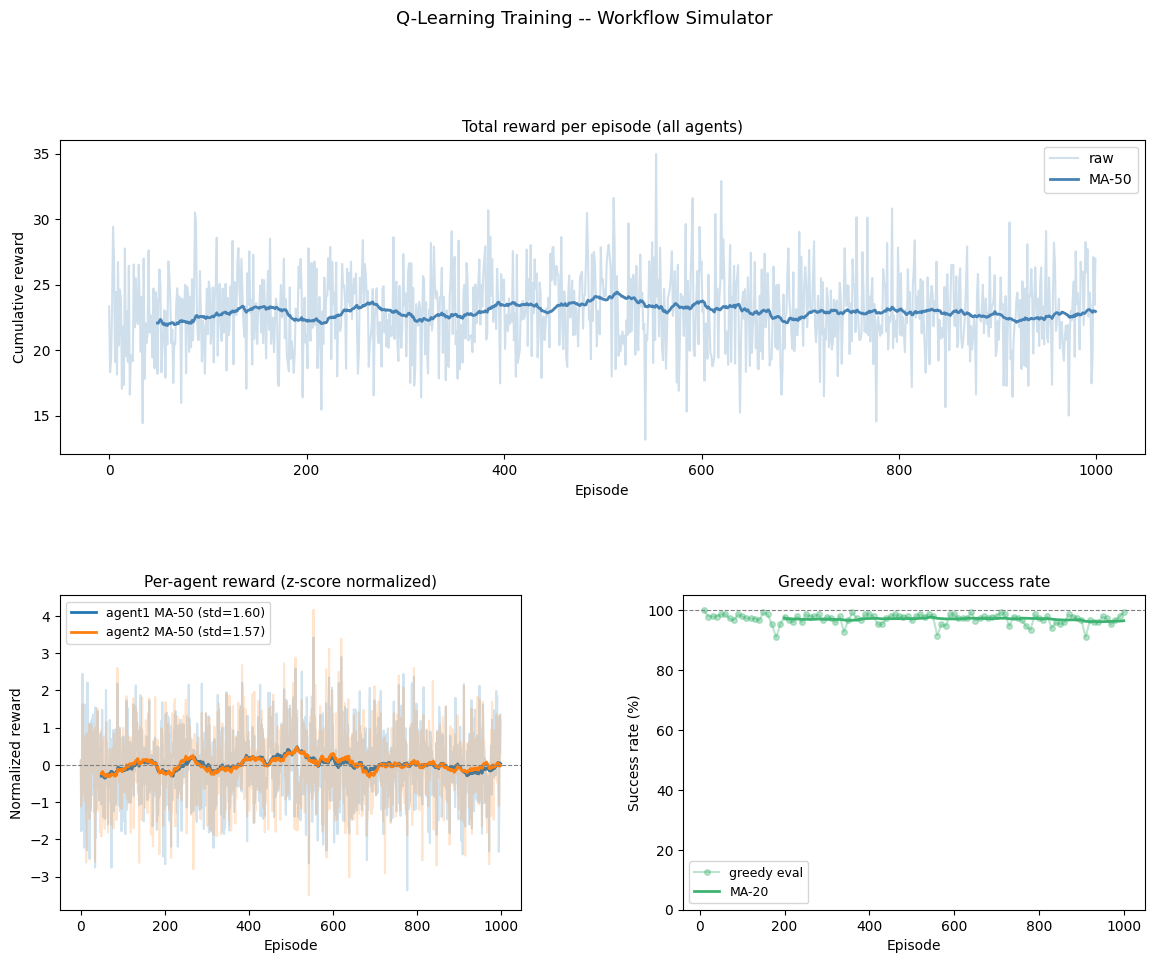

Saved -> training_curves.png


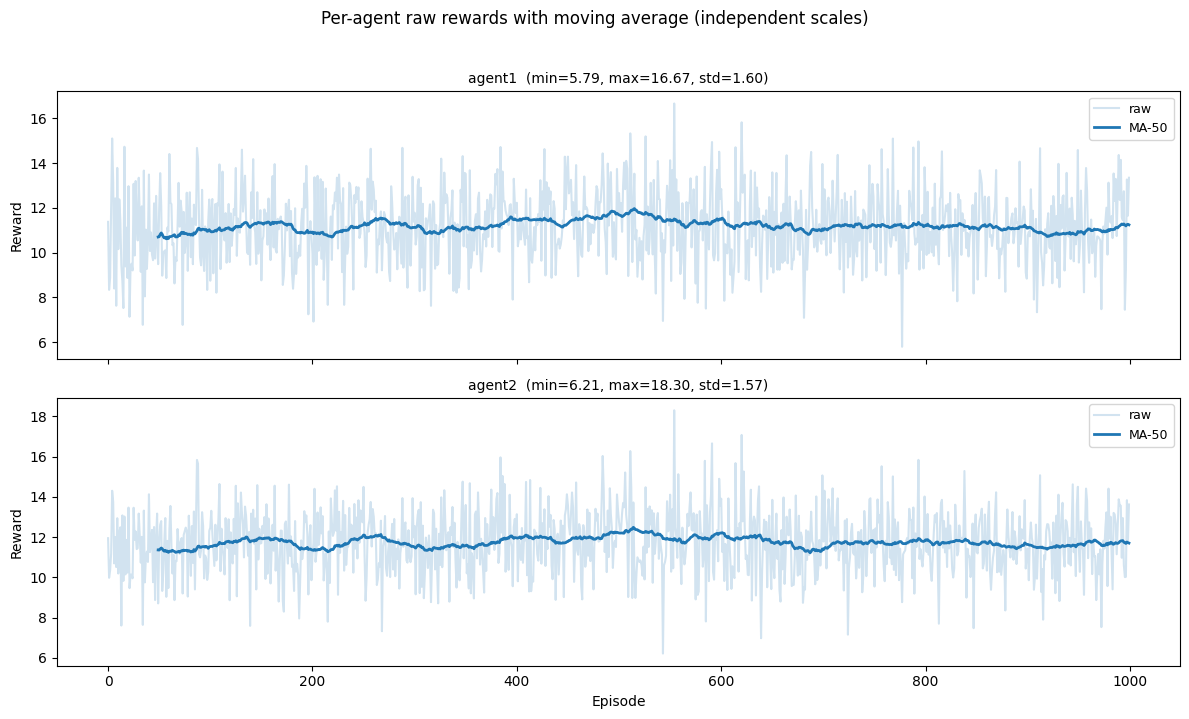

Saved -> training_curves_per_agent_raw.png


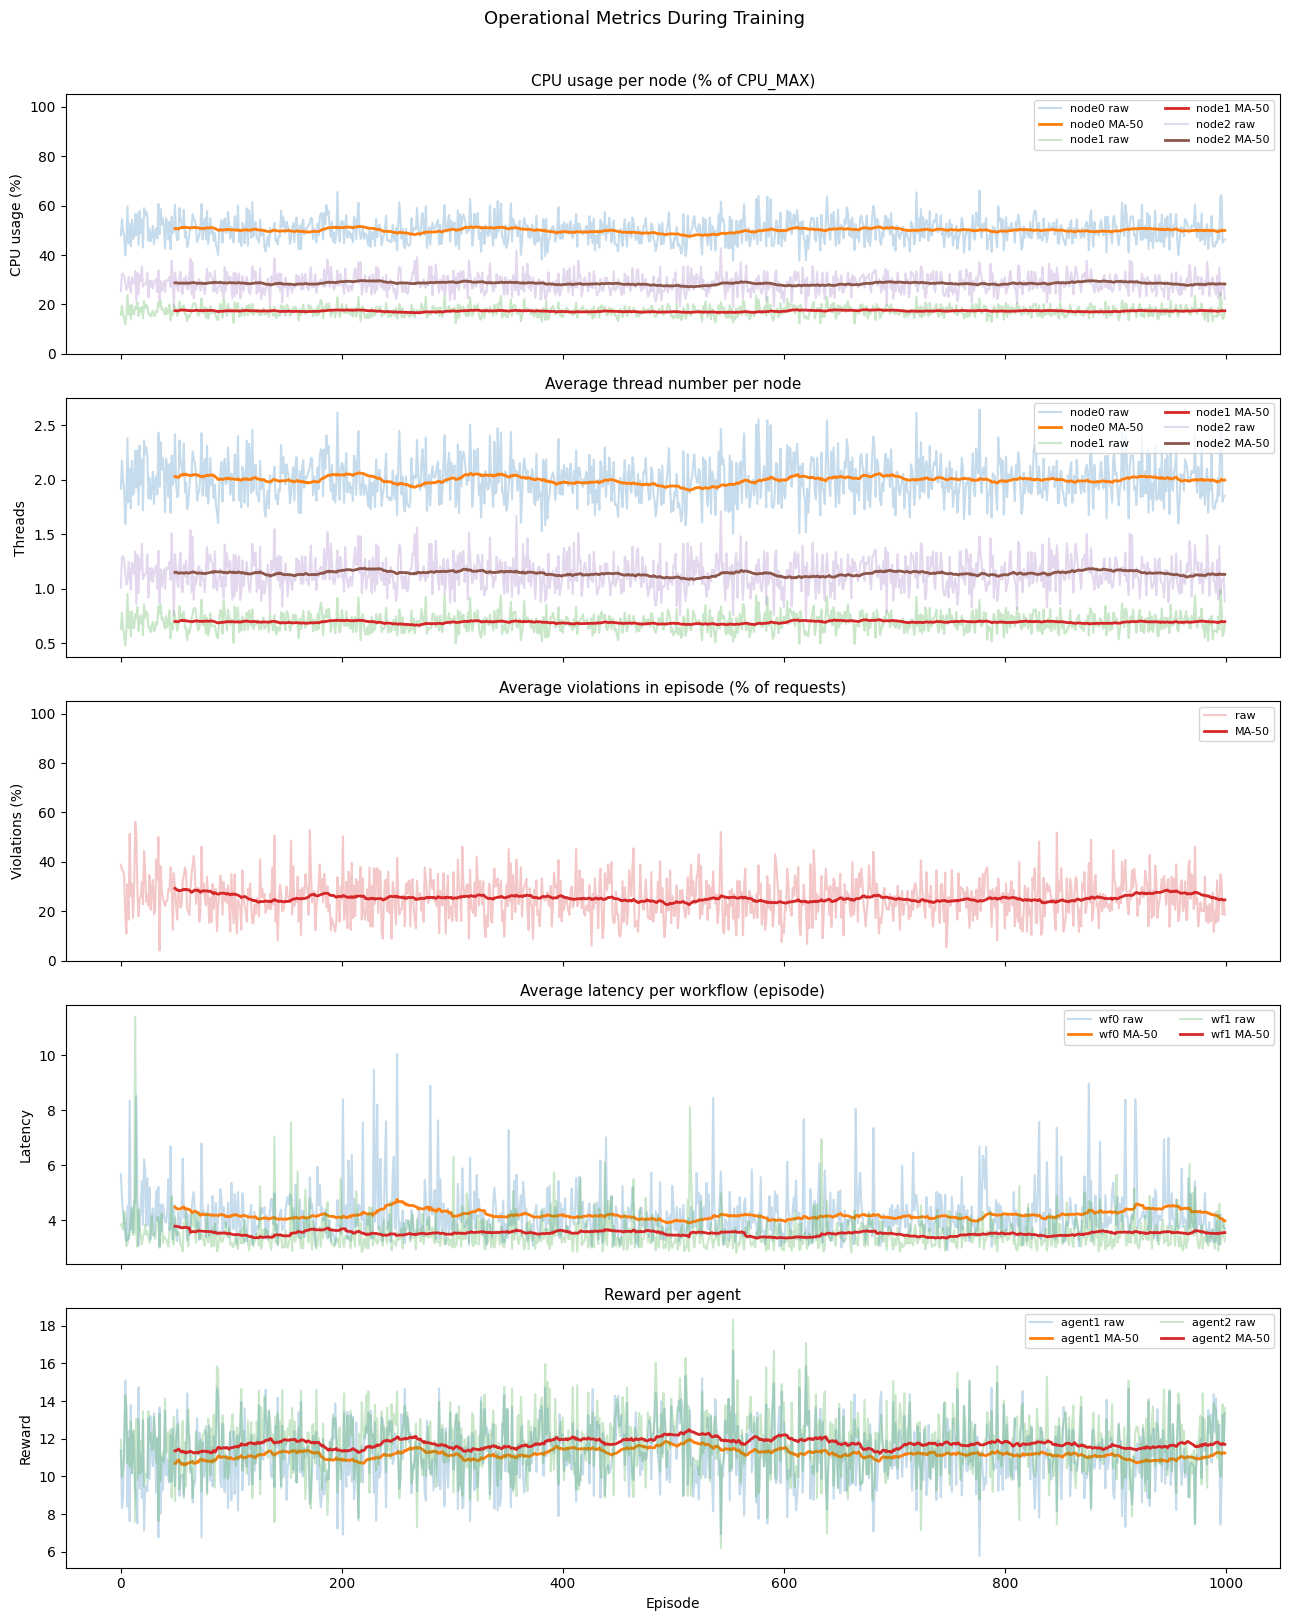

Saved -> training_metrics_requested.png


In [8]:

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

window = max(1, N_EPISODES // 20)

# -- 1. Total reward (smoothed) -----------------------------------------------
ax1 = fig.add_subplot(gs[0, :])
raw = np.array(episode_total_rewards, dtype=float)
smoothed = np.convolve(raw, np.ones(window) / window, mode="valid")
ax1.plot(raw, alpha=0.25, color="steelblue", label="raw")
ax1.plot(range(window - 1, len(raw)), smoothed, color="steelblue", linewidth=2, label=f"MA-{window}")
ax1.set_title("Total reward per episode (all agents)", fontsize=11)
ax1.set_xlabel("Episode")
ax1.set_ylabel("Cumulative reward")
ax1.legend()

# -- 2. Per-agent reward (normalized to avoid scale masking) ------------------
ax2 = fig.add_subplot(gs[1, 0])
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for idx, (agent_name, rewards) in enumerate(episode_per_agent_rewards.items()):
    arr = np.array(rewards, dtype=float)
    mu = float(arr.mean())
    sigma = float(arr.std())
    norm = (arr - mu) / (sigma + 1e-9)
    c = colors[idx % len(colors)]
    ax2.plot(norm, color=c, alpha=0.20)
    smoothed_norm = np.convolve(norm, np.ones(window) / window, mode="valid")
    ax2.plot(range(window - 1, len(norm)), smoothed_norm, color=c, linewidth=2,
             label=f"{agent_name} MA-{window} (std={sigma:.2f})")
ax2.axhline(0.0, linestyle="--", color="grey", linewidth=0.8)
ax2.set_title("Per-agent reward (z-score normalized)", fontsize=11)
ax2.set_xlabel("Episode")
ax2.set_ylabel("Normalized reward")
ax2.legend(fontsize=9)

# -- 3. Greedy success rate ----------------------------------------------------
ax3 = fig.add_subplot(gs[1, 1])
if greedy_episodes:
    ax3.plot(greedy_episodes, greedy_success_rates, marker="o", color="mediumseagreen",
             alpha=0.35, markersize=4, label="greedy eval")
    if len(greedy_success_rates) >= 3:
        gs_arr = np.array(greedy_success_rates, dtype=float)
        gs_window = max(1, len(gs_arr) // 5)
        gs_smoothed = np.convolve(gs_arr, np.ones(gs_window) / gs_window, mode="valid")
        ax3.plot(greedy_episodes[gs_window - 1:], gs_smoothed, color="mediumseagreen",
                 linewidth=2, label=f"MA-{gs_window}")
    ax3.legend(fontsize=9)
ax3.set_ylim(0, 105)
ax3.axhline(100, linestyle="--", color="grey", linewidth=0.8)
ax3.set_title("Greedy eval: workflow success rate", fontsize=11)
ax3.set_xlabel("Episode")
ax3.set_ylabel("Success rate (%)")

plt.suptitle("Q-Learning Training -- Workflow Simulator", fontsize=13, y=1.01)
plt.savefig("training_curves.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved -> training_curves.png")

# -- Additional raw per-agent figure (independent y-scales, with MA) ----------
agent_names_list = list(episode_per_agent_rewards.keys())
fig2, axes = plt.subplots(len(agent_names_list), 1, figsize=(12, 3.5 * len(agent_names_list)), sharex=True)
if len(agent_names_list) == 1:
    axes = [axes]

for i, name in enumerate(agent_names_list):
    arr = np.array(episode_per_agent_rewards[name], dtype=float)
    smoothed_raw = np.convolve(arr, np.ones(window) / window, mode="valid")
    axes[i].plot(arr, color="tab:blue", alpha=0.20, label="raw")
    axes[i].plot(range(window - 1, len(arr)), smoothed_raw, color="tab:blue", linewidth=2,
                 label=f"MA-{window}")
    axes[i].set_title(
        f"{name}  (min={arr.min():.2f}, max={arr.max():.2f}, std={arr.std():.2f})", fontsize=10
    )
    axes[i].set_ylabel("Reward")
    axes[i].legend(fontsize=9)

axes[-1].set_xlabel("Episode")
fig2.suptitle("Per-agent raw rewards with moving average (independent scales)", fontsize=12, y=1.02)
fig2.tight_layout()
fig2.savefig("training_curves_per_agent_raw.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved -> training_curves_per_agent_raw.png")

# -- Requested metrics figure ---------------------------------------------------
fig3, axes3 = plt.subplots(5, 1, figsize=(13, 16), sharex=True)

# 1) CPU usage percentage per node
for node_id in sorted(episode_node_cpu_usage_pct.keys()):
    arr = np.array(episode_node_cpu_usage_pct[node_id], dtype=float)
    axes3[0].plot(arr, alpha=0.25, label=f"node{node_id} raw")
    sm = np.convolve(arr, np.ones(window) / window, mode="valid")
    axes3[0].plot(range(window - 1, len(arr)), sm, linewidth=2, label=f"node{node_id} MA-{window}")
axes3[0].set_title("CPU usage per node (% of CPU_MAX)", fontsize=11)
axes3[0].set_ylabel("CPU usage (%)")
axes3[0].set_ylim(0.0, 105.0)
axes3[0].legend(fontsize=8, ncol=2)

# 2) Average thread number per node
for node_id in sorted(episode_node_avg_threads.keys()):
    arr = np.array(episode_node_avg_threads[node_id], dtype=float)
    axes3[1].plot(arr, alpha=0.25, label=f"node{node_id} raw")
    sm = np.convolve(arr, np.ones(window) / window, mode="valid")
    axes3[1].plot(range(window - 1, len(arr)), sm, linewidth=2, label=f"node{node_id} MA-{window}")
axes3[1].set_title("Average thread number per node", fontsize=11)
axes3[1].set_ylabel("Threads")
axes3[1].legend(fontsize=8, ncol=2)

# 3) Average violations percentage in episode
arr_viol = np.array(episode_avg_violation_pct, dtype=float)
axes3[2].plot(arr_viol, alpha=0.25, color="tab:red", label="raw")
sm_viol = np.convolve(arr_viol, np.ones(window) / window, mode="valid")
axes3[2].plot(range(window - 1, len(arr_viol)), sm_viol, linewidth=2, color="tab:red", label=f"MA-{window}")
axes3[2].set_title("Average violations in episode (% of requests)", fontsize=11)
axes3[2].set_ylabel("Violations (%)")
axes3[2].set_ylim(0.0, 105.0)
axes3[2].legend(fontsize=8)

# 4) Average latency per workflow in episode
for wf_id in sorted(episode_workflow_avg_latency.keys()):
    arr = np.array(episode_workflow_avg_latency[wf_id], dtype=float)
    axes3[3].plot(arr, alpha=0.25, label=f"wf{wf_id} raw")
    sm = np.convolve(arr, np.ones(window) / window, mode="valid")
    axes3[3].plot(range(window - 1, len(arr)), sm, linewidth=2, label=f"wf{wf_id} MA-{window}")
axes3[3].set_title("Average latency per workflow (episode)", fontsize=11)
axes3[3].set_ylabel("Latency")
axes3[3].legend(fontsize=8, ncol=2)

# 5) Reward per agent
for agent_name in sorted(episode_per_agent_rewards.keys()):
    arr = np.array(episode_per_agent_rewards[agent_name], dtype=float)
    axes3[4].plot(arr, alpha=0.25, label=f"{agent_name} raw")
    sm = np.convolve(arr, np.ones(window) / window, mode="valid")
    axes3[4].plot(range(window - 1, len(arr)), sm, linewidth=2, label=f"{agent_name} MA-{window}")
axes3[4].set_title("Reward per agent", fontsize=11)
axes3[4].set_ylabel("Reward")
axes3[4].set_xlabel("Episode")
axes3[4].legend(fontsize=8, ncol=2)

fig3.suptitle("Operational Metrics During Training", fontsize=13, y=1.01)
fig3.tight_layout()
fig3.savefig("training_metrics_requested.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved -> training_metrics_requested.png")


## Step 9 — Save Model & Metadata

The trained model is persisted in `models/run_<timestamp>/`:

| File | Contents |
|---|---|
| `qtables.pkl` | Python `dict` mapping `service_id → Q-table` (tuple keys preserved) |
| `qtables.json` | Human-readable JSON version of the Q-tables (keys stringified) |
| `metadata.json` | Full record of agent config, simulation config, and per-service responsibilities |

The **responsibilities** section records for each service:
- Whether it controls replicas / placement
- The exact node pool available for placement
- The CPU range used for replica control
- The full action space (`node_id, cpu` for every action index)
- Number of Q-states actually visited during training

In [9]:

run_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = MODELS_DIR / f"run_{run_ts}"
run_dir.mkdir(parents=True, exist_ok=True)

# -- Q-tables: pickle (canonical) ---------------------------------------------
qtables = global_dispatcher.qtables()

qtables_pkl_path = run_dir / "qtables.pkl"
with open(qtables_pkl_path, "wb") as f:
    pickle.dump(qtables, f)

# -- Q-tables: JSON (human-readable) ------------------------------------------
def q_table_to_json(q_table):
    return {
        str(k): {str(a): float(v) for a, v in actions.items()}
        for k, actions in q_table.items()
    }

qtables_json_path = run_dir / "qtables.json"
with open(qtables_json_path, "w") as f:
    json.dump(
        {name: q_table_to_json(qt) for name, qt in qtables.items()},
        f,
        indent=2,
    )

# -- Responsibilities: one entry per global agent -----------------------------
responsibilities = []
for item in global_agents:
    responsibilities.append(
        {
            "agent_name": item["name"],
            "assignments": [
                {"service_id": sid, "control": ctrl}
                for sid, ctrl in item["responsibilities"]
            ],
            "workflow_scope": item["workflow_scope"],
            "n_actions": len(item["action_space"]),
            "sample_action": item["action_space"][0] if item["action_space"] else {},
            "q_table_states_visited": len(item["agent"].q_table),
        }
    )

workflow_info = []
for wf in app.workflows:
    workflow_info.append(
        {
            "workflow_id": wf.id,
            "task_nodes": wf.nodes,
            "arrival_rate_lambda": float(wf.lam),
        }
    )

metadata = {
    "created_at": run_ts,
    "training": {
        "n_episodes": N_EPISODES,
        "iterations_per_episode": ITERATIONS,
        "eval_interval": EVAL_INTERVAL,
        "seed": SEED,
        "final_episode_reward": float(episode_total_rewards[-1]),
        "best_episode_reward": float(max(episode_total_rewards)),
        "final_greedy_success_rate": float(greedy_success_rates[-1]) if greedy_success_rates else None,
        "best_greedy_success_rate": float(max(greedy_success_rates)) if greedy_success_rates else None,
    },
    "agent_config": {
        "type": "QLearningAgent",
        "dispatcher": "GlobalAgentDispatcher",
        "epsilon_init": EPSILON,
        "epsilon_min": EPSILON_MIN,
        "epsilon_decay": EPSILON_DECAY,
        "alpha": ALPHA,
        "gamma": GAMMA,
        "e2e_latency_target": E2E_LAT_TARGET,
        "reward_cpu_weight": REWARD_CPU_WEIGHT,
        "reward_latency_violation_weight": REWARD_LAT_VIOL_WEIGHT,
        "state_shape": "agent-scoped [service_queues..., service_cpus...]",
        "reward_shape": (
            "negative weighted sum of normalized penalties: "
            "cpu_weight * mean(node_cpu_consumption_norm) + "
            "lat_weight * mean(latency_violation_norm)"
        ),
        "assignment_input": AGENT_CONTROL_ASSIGNMENTS,
    },
    "simulation_config": {
        "n_services": len(app.services),
        "n_workflows": len(app.workflows),
        "n_nodes": N_NODES,
        "cpu_max": CPU_MAX,
        "ram": RAM,
        "freq": FREQ,
        "timeout": TIMEOUT,
    },
    "responsibilities": responsibilities,
    "workflows": workflow_info,
    "files": {
        "qtables_pickle": "qtables.pkl",
        "qtables_json": "qtables.json",
        "metadata": "metadata.json",
    },
}

meta_path = run_dir / "metadata.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Model saved -> {run_dir}/")
print(f"  qtables.pkl    {qtables_pkl_path.stat().st_size:>8,} bytes")
print(f"  qtables.json   {qtables_json_path.stat().st_size:>8,} bytes")
print(f"  metadata.json  {meta_path.stat().st_size:>8,} bytes")


Model saved -> models/run_20260327_124124/
  qtables.pkl     143,310 bytes
  qtables.json    249,924 bytes
  metadata.json     2,524 bytes


## Step 10 — Verify Saved Artefacts

Load the metadata file and the Q-tables back from disk and print a summary.
This confirms the files are well-formed and the Q-tables are intact.

In [10]:
# -- Load metadata -------------------------------------------------------------
with open(run_dir / "metadata.json") as f:
    loaded_meta = json.load(f)

print("=== Agent Config ===")
for k, v in loaded_meta["agent_config"].items():
    print(f"  {k}: {v}")

print("\n=== Simulation Config ===")
for k, v in loaded_meta["simulation_config"].items():
    print(f"  {k}: {v}")

print("\n=== Workflows ===")
for wf in loaded_meta["workflows"]:
    print(
        f"  workflow {wf['workflow_id']}: "
        f"tasks={wf['task_nodes']}  "
        f"lambda={wf['arrival_rate_lambda']:.4f}"
    )

print("\n=== Agent Responsibilities ===")
for r in loaded_meta["responsibilities"]:
    readable = [f"s{a['service_id']}.{a['control']}" for a in r["assignments"]]
    print(
        f"  agent={r['agent_name']} | "
        f"assignments={readable} | "
        f"n_actions={r['n_actions']} | "
        f"q_states_visited={r['q_table_states_visited']}"
    )

print("\n=== Training Summary ===")
tr = loaded_meta["training"]
print(f"  episodes             : {tr['n_episodes']}")
print(f"  final episode reward : {tr['final_episode_reward']:.3f}")
print(f"  best  episode reward : {tr['best_episode_reward']:.3f}")
if tr["final_greedy_success_rate"] is not None:
    print(f"  final greedy success : {tr['final_greedy_success_rate']:.1f}%")
    print(f"  best  greedy success : {tr['best_greedy_success_rate']:.1f}%")

# -- Load Q-tables from pickle -------------------------------------------------
with open(run_dir / "qtables.pkl", "rb") as f:
    loaded_qtables = pickle.load(f)

print("\n=== Q-Tables (loaded from pickle) ===")
for agent_name, qt in loaded_qtables.items():
    print(f"  {agent_name}: {len(qt)} states visited")

=== Agent Config ===
  type: QLearningAgent
  dispatcher: GlobalAgentDispatcher
  epsilon_init: 0.3
  epsilon_min: 0.05
  epsilon_decay: 0.992
  alpha: 0.1
  gamma: 0.9
  e2e_latency_target: 4.0
  reward_cpu_weight: 0.5
  reward_latency_violation_weight: 0.5
  state_shape: agent-scoped [service_queues..., service_cpus...]
  reward_shape: negative weighted sum of normalized penalties: cpu_weight * mean(node_cpu_consumption_norm) + lat_weight * mean(latency_violation_norm)
  assignment_input: {'s1.scaling': 'agent1', 's2.scaling': 'agent1', 's3.scaling': 'agent2', 's4.scaling': 'agent2'}

=== Simulation Config ===
  n_services: 4
  n_workflows: 2
  n_nodes: 3
  cpu_max: 4
  ram: 8
  freq: 1000
  timeout: 600000

=== Workflows ===
  workflow 0: tasks=[0, 1]  lambda=0.5000
  workflow 1: tasks=[2, 3]  lambda=0.4000

=== Agent Responsibilities ===
  agent=agent1 | assignments=['s0.cpu', 's1.cpu'] | n_actions=16 | q_states_visited=440
  agent=agent2 | assignments=['s2.cpu', 's3.cpu'] | n_acti